# 📈 Task 2: Predict Future Stock Prices (Short-Term)

## Problem Statement
Stock markets are inherently volatile, but short-term price movements often exhibit patterns based on recent trading history. In this task, we use **Apple Inc. (AAPL)** historical data fetched via `yfinance` to predict the **next day's closing price** using regression models.

## Goal
- Fetch real stock data using the `yfinance` API
- Engineer lag-based and rolling features for time series modeling
- Train **Linear Regression** and **Random Forest** models
- Evaluate models using MAE, RMSE, and R² score
- Visualize actual vs predicted closing prices

## Approach
> We frame this as a **supervised regression problem**: given today's Open, High, Low, Close, and Volume, predict **tomorrow's Close** price.

---

## Step 1: Install & Import Libraries

In [1]:
# Install yfinance (not pre-installed in Colab)
!pip install yfinance --quiet
print('✅ yfinance installed!')

✅ yfinance installed!


In [2]:
import yfinance as yf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Scikit-learn: preprocessing, models, evaluation
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# Plot style
sns.set_theme(style='whitegrid', font_scale=1.05)
plt.rcParams['figure.dpi'] = 120
plt.rcParams['axes.titleweight'] = 'bold'

print('✅ All libraries imported successfully!')

✅ All libraries imported successfully!


---
## Step 2: Fetch Stock Data via yfinance API

In [3]:
# --- Configuration ---
TICKER   = 'AAPL'    # Apple Inc. — change to 'TSLA', 'MSFT', 'GOOGL', etc.
START    = '2020-01-01'
END      = '2024-12-31'

# Fetch data from Yahoo Finance
print(f'📡 Fetching {TICKER} data from {START} to {END}...')
raw = yf.download(TICKER, start=START, end=END, progress=False)

# yfinance returns MultiIndex columns — flatten them
if isinstance(raw.columns, pd.MultiIndex):
    raw.columns = raw.columns.get_level_values(0)

print(f'✅ Downloaded {len(raw):,} trading days of data.')
print(f'📅 Date range: {raw.index[0].date()} → {raw.index[-1].date()}')
raw.head()

📡 Fetching AAPL data from 2020-01-01 to 2024-12-31...
✅ Downloaded 1,257 trading days of data.
📅 Date range: 2020-01-02 → 2024-12-30


Price,Close,High,Low,Open,Volume
Date,,,,,
2020-01-02,72.333878,72.394086,71.091184,71.344054,135480400
2020-01-03,71.630630,72.389250,71.406659,71.563198,146322800
2020-01-06,72.201424,72.239958,70.503561,70.754028,118387200
2020-01-07,71.861839,72.466322,71.642681,72.211041,108872000
2020-01-08,73.017853,73.318893,71.565636,71.565636,132079200


In [4]:
# Basic info about the raw data
print('📋 Dataset Shape:', raw.shape)
print('\n📊 Summary Statistics:')
raw.describe().round(2)

📋 Dataset Shape: (1257, 5)

📊 Summary Statistics:


Price,Close,High,Low,Open,Volume
count,1257.00,1257.00,1257.00,1257.00,1.257000e+03
mean,151.30,152.82,149.60,151.14,9.061168e+07
std,41.78,41.92,41.55,41.72,5.324605e+07
min,54.16,55.16,51.32,55.06,2.323470e+07
25%,126.25,127.33,124.23,125.72,5.546960e+07
50%,149.94,151.69,147.95,149.77,7.629970e+07
75%,175.75,177.44,174.32,175.59,1.077601e+08
max,257.38,258.45,255.99,256.55,4.265100e+08


---
## Step 3: Exploratory Data Analysis (EDA)

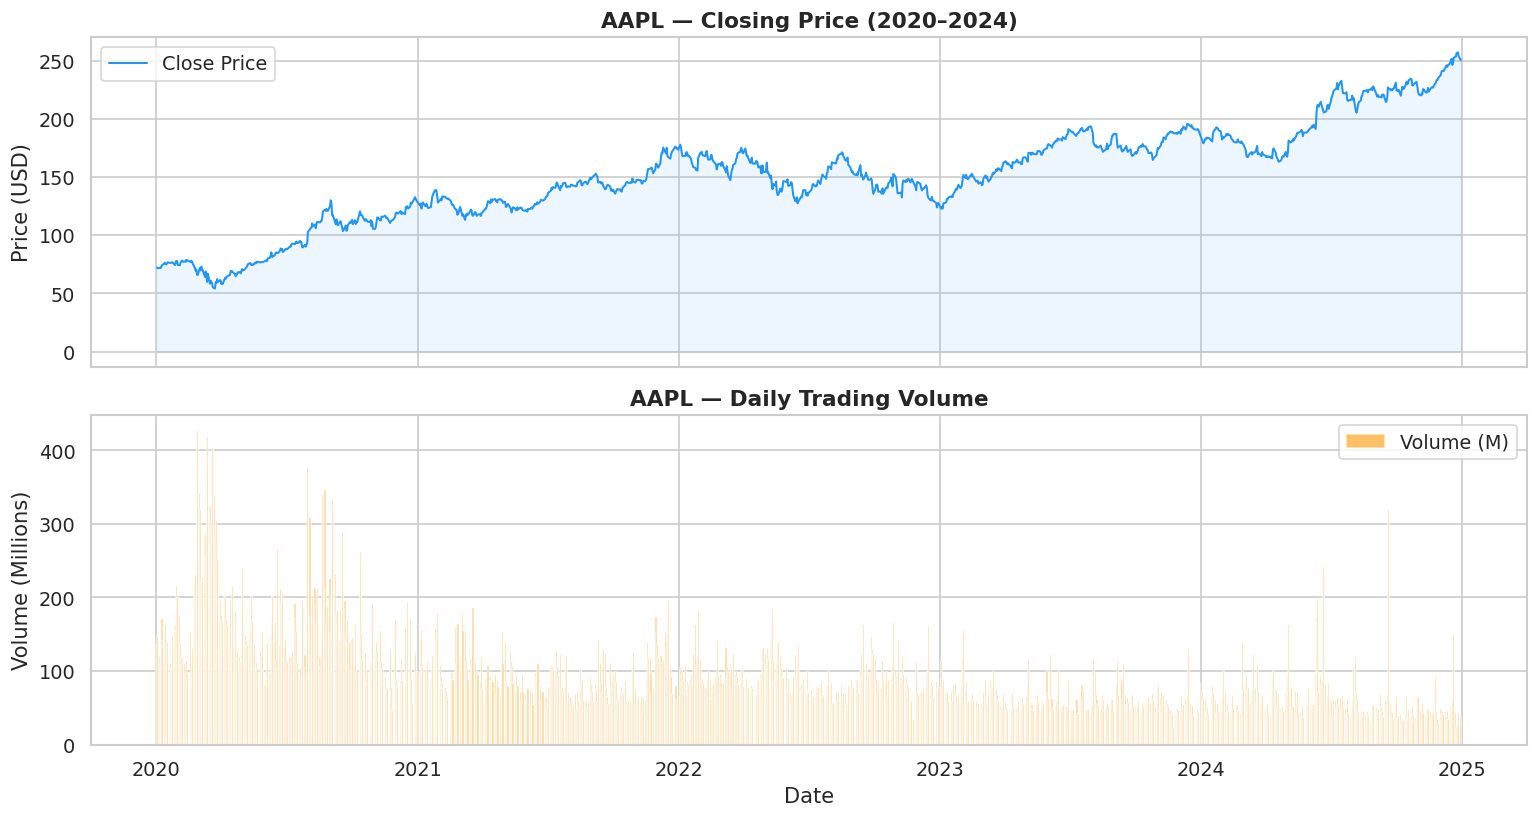

In [5]:
# --- Plot 1: Closing Price Over Time ---
fig, axes = plt.subplots(2, 1, figsize=(13, 7), sharex=True)

# Closing price
axes[0].plot(raw.index, raw['Close'], color='#2196F3', linewidth=1.2, label='Close Price')
axes[0].fill_between(raw.index, raw['Close'], alpha=0.08, color='#2196F3')
axes[0].set_title(f'{TICKER} — Closing Price (2020–2024)', fontsize=13)
axes[0].set_ylabel('Price (USD)')
axes[0].legend()

# Volume
axes[1].bar(raw.index, raw['Volume'] / 1e6, color='#FF9800', alpha=0.6, width=1.5, label='Volume (M)')
axes[1].set_title(f'{TICKER} — Daily Trading Volume', fontsize=13)
axes[1].set_ylabel('Volume (Millions)')
axes[1].set_xlabel('Date')
axes[1].legend()

plt.tight_layout()
plt.show()

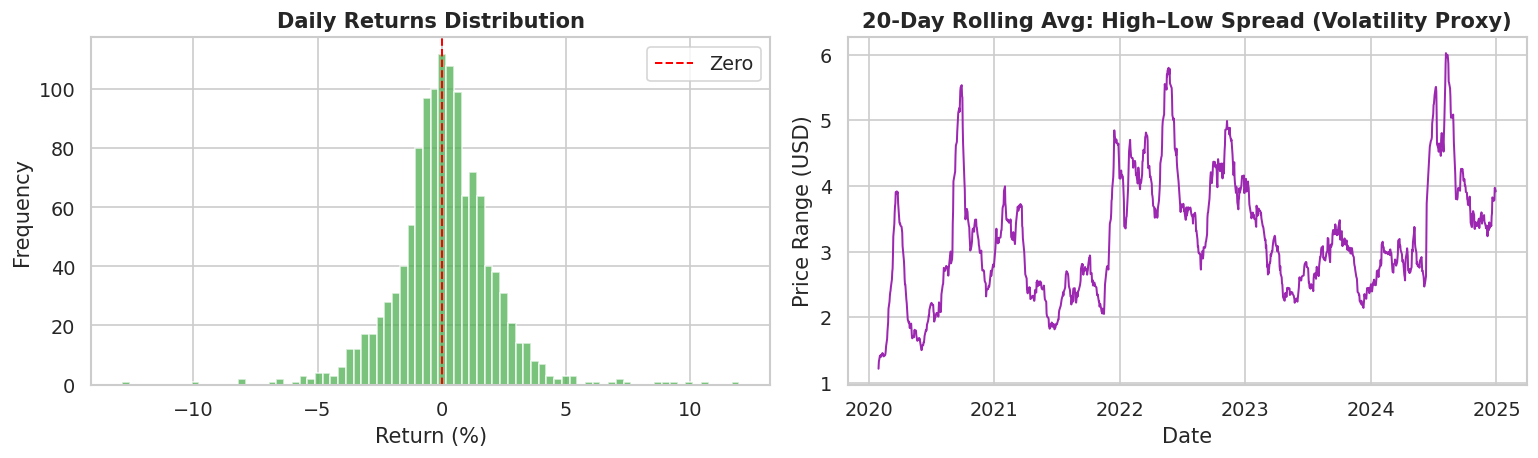

📊 Average daily return : 0.119%
📊 Std dev of returns   : 1.996%


In [6]:
# --- Daily Returns Distribution ---
raw['Daily_Return'] = raw['Close'].pct_change() * 100  # percentage

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

# Histogram of daily returns
axes[0].hist(raw['Daily_Return'].dropna(), bins=80, color='#4CAF50', alpha=0.75, edgecolor='white')
axes[0].axvline(0, color='red', linestyle='--', linewidth=1.2, label='Zero')
axes[0].set_title('Daily Returns Distribution')
axes[0].set_xlabel('Return (%)')
axes[0].set_ylabel('Frequency')
axes[0].legend()

# Candlestick-style OHLC range (High - Low spread)
raw['HL_Spread'] = raw['High'] - raw['Low']
axes[1].plot(raw.index, raw['HL_Spread'].rolling(20).mean(), color='#9C27B0', linewidth=1.2)
axes[1].set_title('20-Day Rolling Avg: High–Low Spread (Volatility Proxy)')
axes[1].set_xlabel('Date')
axes[1].set_ylabel('Price Range (USD)')

plt.tight_layout()
plt.show()

print(f'📊 Average daily return : {raw["Daily_Return"].mean():.3f}%')
print(f'📊 Std dev of returns   : {raw["Daily_Return"].std():.3f}%')

---
## Step 4: Feature Engineering

> **Key Idea**: We predict **tomorrow's Close** (`Target`). To avoid data leakage, all features are computed from *current or past* data only.

In [7]:
df = raw[['Open', 'High', 'Low', 'Close', 'Volume']].copy()

# ── 1. Target: next day's closing price ─────────────────────────────
df['Target'] = df['Close'].shift(-1)   # shift -1 = tomorrow's close

# ── 2. Lag features: yesterday's and the day before's close ─────────
df['Close_Lag1'] = df['Close'].shift(1)
df['Close_Lag2'] = df['Close'].shift(2)
df['Close_Lag3'] = df['Close'].shift(3)

# ── 3. Rolling statistics (past N days) ─────────────────────────────
df['MA_5']   = df['Close'].rolling(5).mean()    # 5-day moving average
df['MA_10']  = df['Close'].rolling(10).mean()   # 10-day moving average
df['MA_20']  = df['Close'].rolling(20).mean()   # 20-day moving average
df['STD_5']  = df['Close'].rolling(5).std()     # 5-day rolling std
df['STD_10'] = df['Close'].rolling(10).std()    # 10-day rolling std

# ── 4. Price-derived features ────────────────────────────────────────
df['HL_Range']    = df['High'] - df['Low']           # intraday range
df['OC_Change']   = df['Close'] - df['Open']         # open-to-close movement
df['Daily_Ret']   = df['Close'].pct_change()         # daily return
df['Momentum_5']  = df['Close'] - df['Close'].shift(5)  # 5-day momentum

# ── 5. Volume feature ────────────────────────────────────────────────
df['Volume_MA5']  = df['Volume'].rolling(5).mean()   # smoothed volume

# Drop rows with NaN (from rolling/lag operations)
df.dropna(inplace=True)

print(f'✅ Feature engineering complete!')
print(f'📐 Dataset after dropping NaNs: {df.shape}')
print(f'\n📌 Features created:')
print([c for c in df.columns if c != 'Target'])

✅ Feature engineering complete!
📐 Dataset after dropping NaNs: (1237, 19)

📌 Features created:
['Open', 'High', 'Low', 'Close', 'Volume', 'Close_Lag1', 'Close_Lag2', 'Close_Lag3', 'MA_5', 'MA_10', 'MA_20', 'STD_5', 'STD_10', 'HL_Range', 'OC_Change', 'Daily_Ret', 'Momentum_5', 'Volume_MA5']


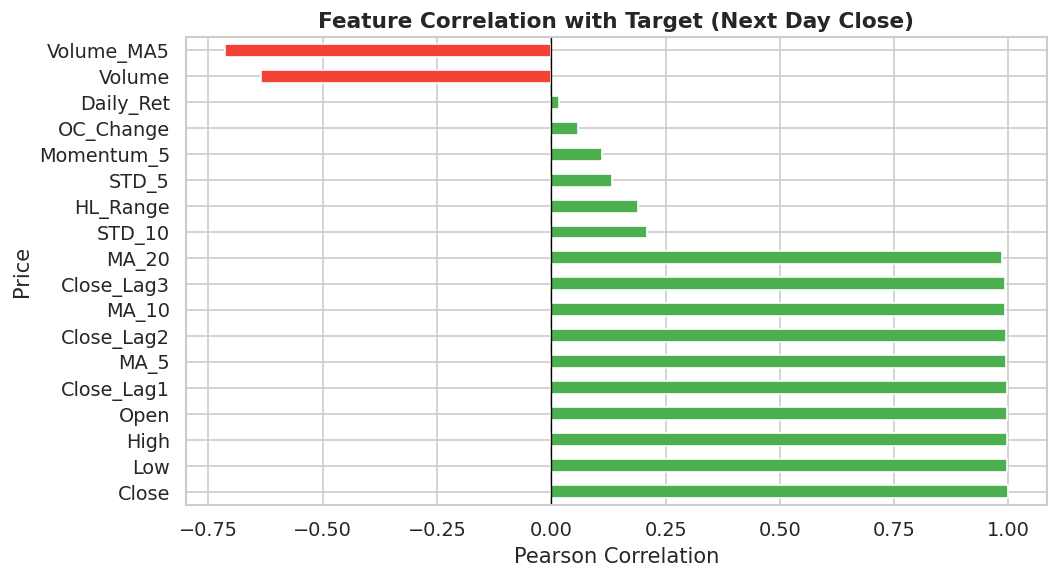


💡 Insight: Close, MA features, and lag prices are most correlated with target — expected for stock data.


In [8]:
# Correlation of all features with the Target
corr_with_target = df.corr()['Target'].drop('Target').sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(9, 5))
colors = ['#4CAF50' if v > 0 else '#F44336' for v in corr_with_target]
corr_with_target.plot(kind='barh', ax=ax, color=colors, edgecolor='white')
ax.axvline(0, color='black', linewidth=0.8)
ax.set_title('Feature Correlation with Target (Next Day Close)', fontsize=13)
ax.set_xlabel('Pearson Correlation')
plt.tight_layout()
plt.show()

print('\n💡 Insight: Close, MA features, and lag prices are most correlated with target — expected for stock data.')

---
## Step 5: Prepare Train / Test Split

> ⚠️ For time series data, we must **NOT** use random splitting — it causes data leakage from the future. We use a **chronological split** instead (80% train, 20% test).

In [9]:
# Define feature columns (everything except Target)
FEATURE_COLS = [c for c in df.columns if c != 'Target']
X = df[FEATURE_COLS]
y = df['Target']

# Chronological train/test split (no shuffling!)
SPLIT = int(len(df) * 0.80)
X_train, X_test = X.iloc[:SPLIT], X.iloc[SPLIT:]
y_train, y_test = y.iloc[:SPLIT], y.iloc[SPLIT:]
test_dates      = df.index[SPLIT:]

# Scale features (important for Linear Regression)
scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)   # fit on train only
X_test_sc  = scaler.transform(X_test)        # transform test with same scaler

print(f'📅 Train period: {df.index[0].date()} → {df.index[SPLIT-1].date()} ({len(X_train):,} days)')
print(f'📅 Test period : {df.index[SPLIT].date()} → {df.index[-1].date()} ({len(X_test):,} days)')
print(f'🔢 Features    : {len(FEATURE_COLS)}')

📅 Train period: 2020-01-30 → 2024-01-03 (989 days)
📅 Test period : 2024-01-04 → 2024-12-27 (248 days)
🔢 Features    : 18


---
## Step 6: Train Models
### 6.1 — Linear Regression

In [10]:
# Train Linear Regression
lr = LinearRegression()
lr.fit(X_train_sc, y_train)
lr_preds = lr.predict(X_test_sc)

# Evaluation metrics
lr_mae  = mean_absolute_error(y_test, lr_preds)
lr_rmse = np.sqrt(mean_squared_error(y_test, lr_preds))
lr_r2   = r2_score(y_test, lr_preds)

print('━' * 40)
print('   Linear Regression Results')
print('━' * 40)
print(f'  MAE   : ${lr_mae:.4f}')
print(f'  RMSE  : ${lr_rmse:.4f}')
print(f'  R²    : {lr_r2:.6f}')
print('━' * 40)

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
   Linear Regression Results
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
  MAE   : $2.2114
  RMSE  : $2.9498
  R²    : 0.986540
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━


### 6.2 — Random Forest Regressor

In [11]:
# Train Random Forest (no scaling needed for tree models)
rf = RandomForestRegressor(
    n_estimators=200,
    max_depth=10,
    min_samples_split=5,
    random_state=42,
    n_jobs=-1
)
rf.fit(X_train, y_train)
rf_preds = rf.predict(X_test)

# Evaluation metrics
rf_mae  = mean_absolute_error(y_test, rf_preds)
rf_rmse = np.sqrt(mean_squared_error(y_test, rf_preds))
rf_r2   = r2_score(y_test, rf_preds)

print('━' * 40)
print('   Random Forest Results')
print('━' * 40)
print(f'  MAE   : ${rf_mae:.4f}')
print(f'  RMSE  : ${rf_rmse:.4f}')
print(f'  R²    : {rf_r2:.6f}')
print('━' * 40)

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
   Random Forest Results
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
  MAE   : $18.8512
  RMSE  : $25.4119
  R²    : 0.001074
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━


---
## Step 7: Model Comparison

In [12]:
# Side-by-side metrics comparison
results = pd.DataFrame({
    'Model'  : ['Linear Regression', 'Random Forest'],
    'MAE ($)': [round(lr_mae, 4),  round(rf_mae, 4)],
    'RMSE ($)': [round(lr_rmse, 4), round(rf_rmse, 4)],
    'R² Score': [round(lr_r2, 6),  round(rf_r2, 6)]
})
print('\n📊 Model Comparison:')
print(results.to_string(index=False))

winner = 'Random Forest' if rf_r2 > lr_r2 else 'Linear Regression'
print(f'\n🏆 Best Model: {winner} (higher R²)')


📊 Model Comparison:
            Model  MAE ($)  RMSE ($)  R² Score
Linear Regression   2.2114    2.9498  0.986540
    Random Forest  18.8512   25.4119  0.001074

🏆 Best Model: Linear Regression (higher R²)


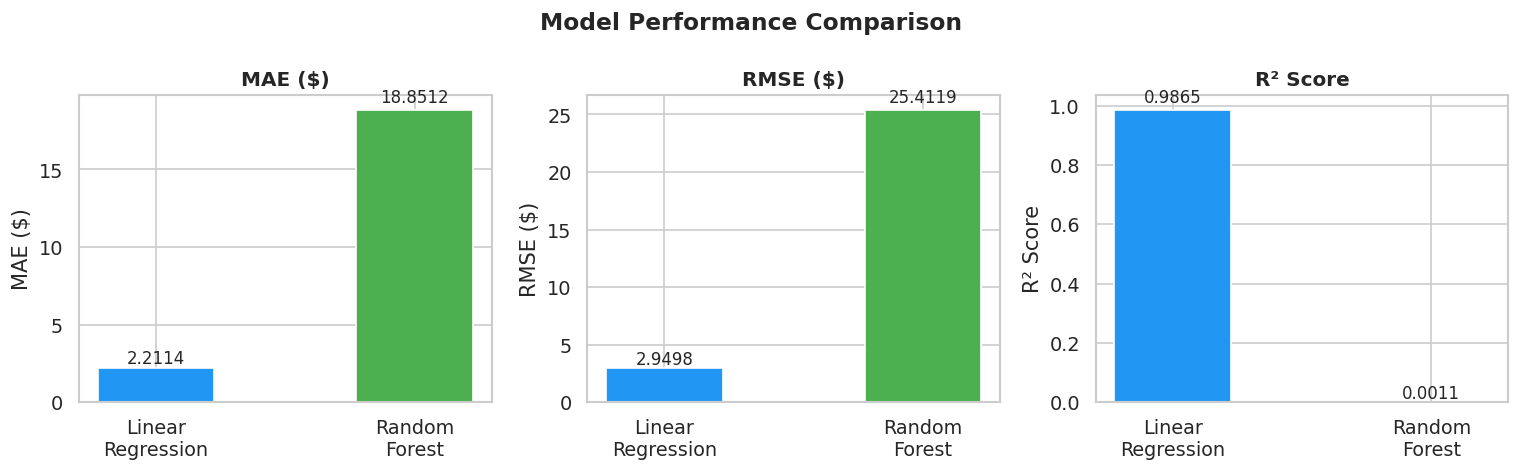

In [13]:
# Bar chart comparing MAE and RMSE
fig, axes = plt.subplots(1, 3, figsize=(13, 4))
metrics   = ['MAE ($)', 'RMSE ($)', 'R² Score']
lr_vals   = [lr_mae, lr_rmse, lr_r2]
rf_vals   = [rf_mae, rf_rmse, rf_r2]
colors    = ['#2196F3', '#4CAF50']

for i, (metric, lv, rv) in enumerate(zip(metrics, lr_vals, rf_vals)):
    axes[i].bar(['Linear\nRegression', 'Random\nForest'], [lv, rv],
                color=colors, edgecolor='white', width=0.45)
    axes[i].set_title(metric, fontsize=12)
    axes[i].set_ylabel(metric)
    for bar, val in zip(axes[i].patches, [lv, rv]):
        axes[i].text(bar.get_x() + bar.get_width()/2,
                     bar.get_height() * 1.01,
                     f'{val:.4f}', ha='center', va='bottom', fontsize=10)

fig.suptitle('Model Performance Comparison', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

---
## Step 8: Visualize Actual vs Predicted Prices

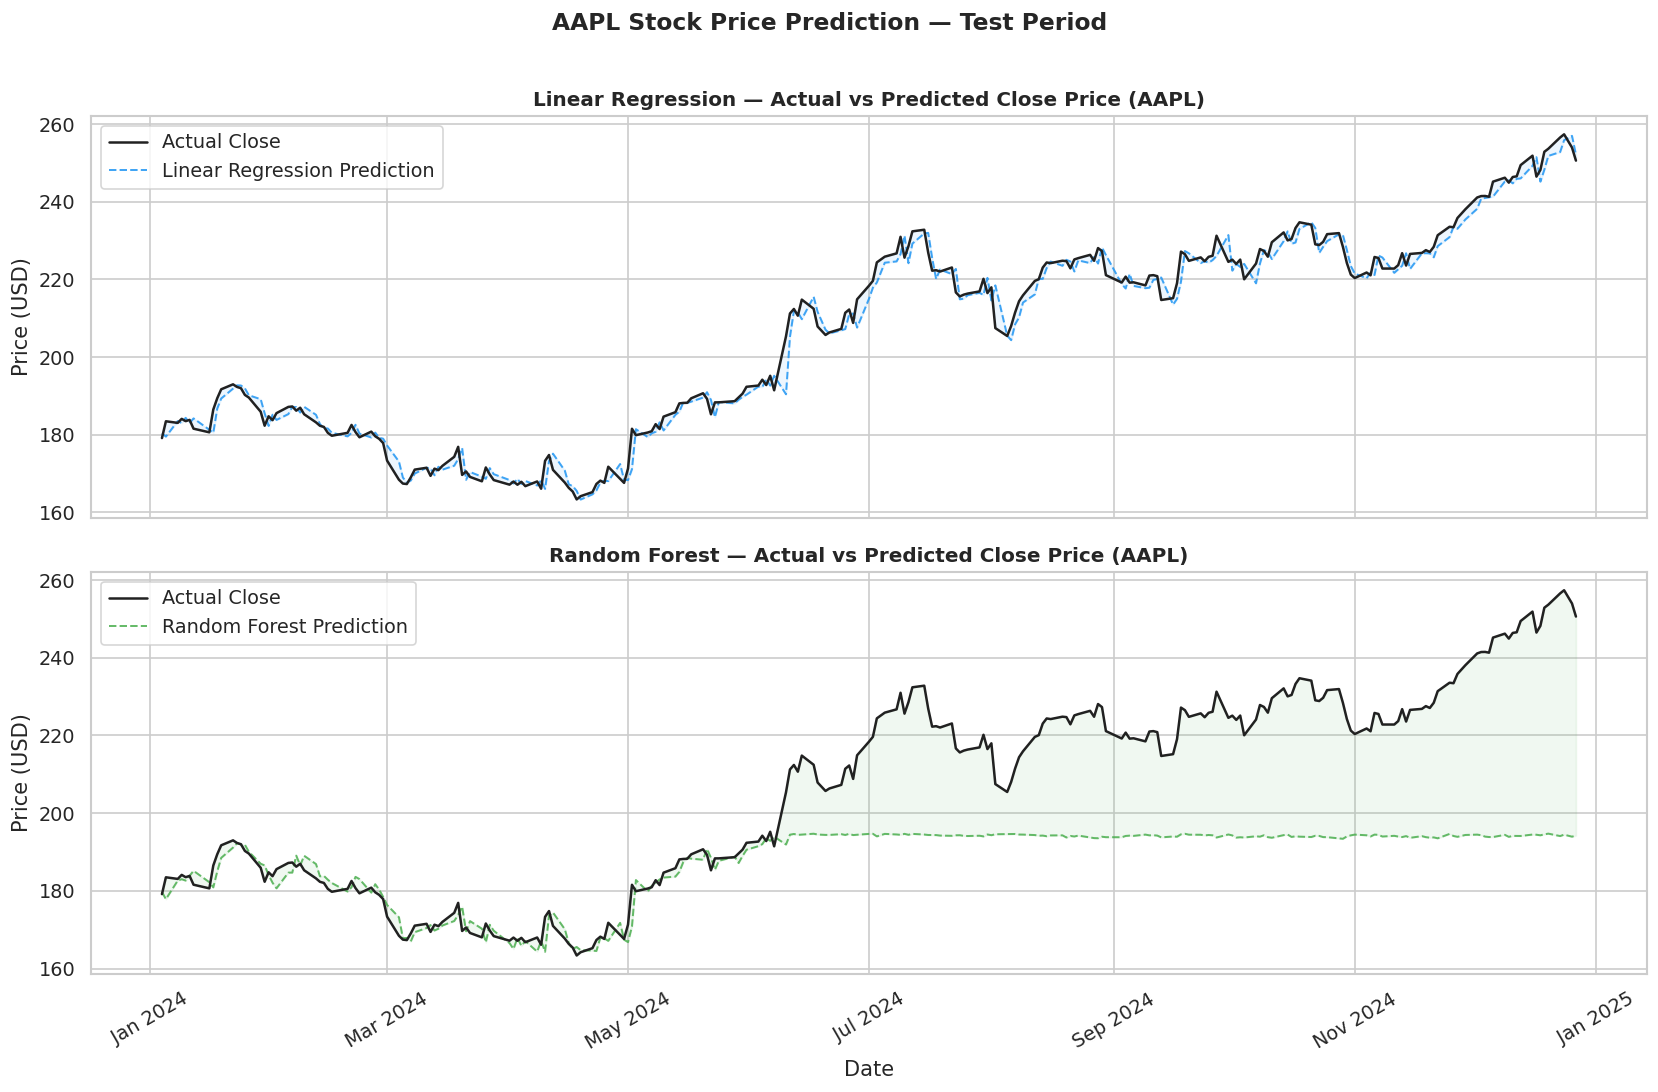

In [14]:
# --- Main Plot: Actual vs Both Models ---
fig, axes = plt.subplots(2, 1, figsize=(14, 9), sharex=True)

for ax, preds, label, color in zip(
    axes,
    [lr_preds, rf_preds],
    ['Linear Regression', 'Random Forest'],
    ['#2196F3', '#4CAF50']
):
    ax.plot(test_dates, y_test.values,
            color='#212121', linewidth=1.5, label='Actual Close', zorder=3)
    ax.plot(test_dates, preds,
            color=color, linewidth=1.2, linestyle='--',
            label=f'{label} Prediction', alpha=0.85, zorder=2)
    ax.fill_between(test_dates, y_test.values, preds,
                    alpha=0.08, color=color)
    ax.set_title(f'{label} — Actual vs Predicted Close Price ({TICKER})', fontsize=12)
    ax.set_ylabel('Price (USD)')
    ax.legend(loc='upper left')
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
    ax.xaxis.set_major_locator(mdates.MonthLocator(interval=2))

axes[1].set_xlabel('Date')
plt.xticks(rotation=30)
plt.suptitle(f'{TICKER} Stock Price Prediction — Test Period', fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

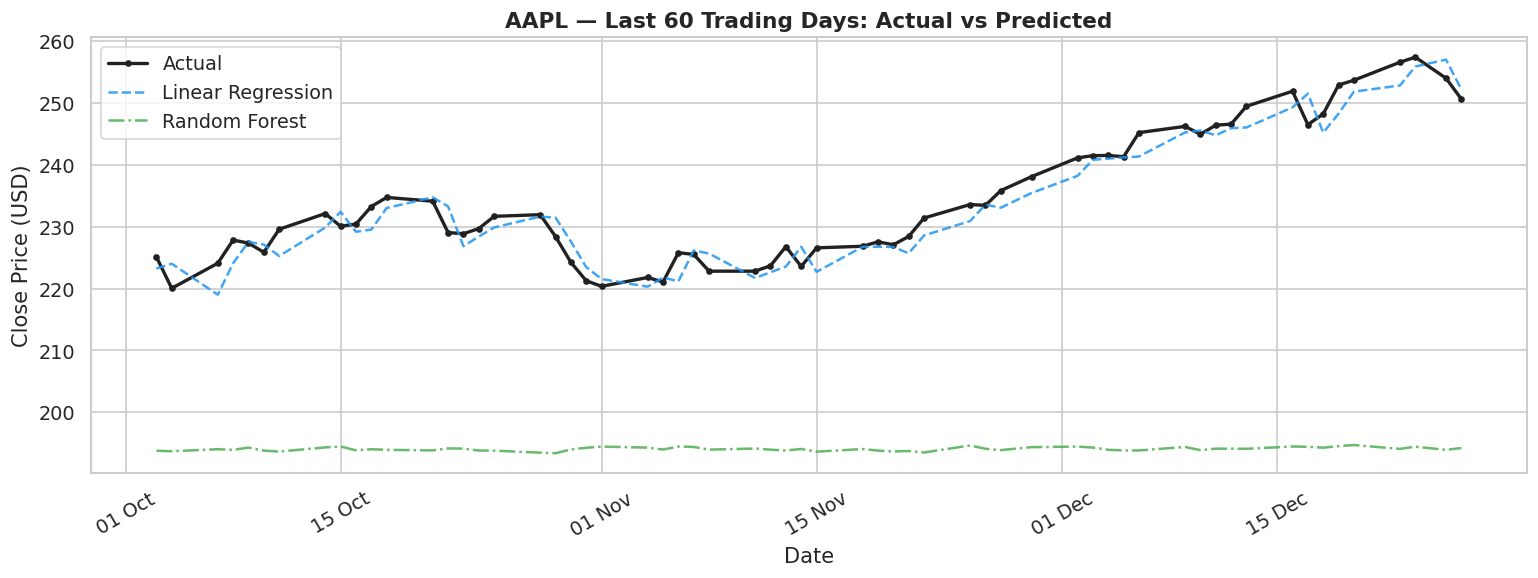

In [15]:
# --- Zoomed-in: Last 60 Trading Days ---
N = 60
fig, ax = plt.subplots(figsize=(13, 5))

ax.plot(test_dates[-N:], y_test.values[-N:],
        color='#212121', linewidth=2, label='Actual', marker='o', markersize=3)
ax.plot(test_dates[-N:], lr_preds[-N:],
        color='#2196F3', linewidth=1.5, linestyle='--', label='Linear Regression', alpha=0.85)
ax.plot(test_dates[-N:], rf_preds[-N:],
        color='#4CAF50', linewidth=1.5, linestyle='-.', label='Random Forest', alpha=0.85)

ax.set_title(f'{TICKER} — Last {N} Trading Days: Actual vs Predicted', fontsize=13)
ax.set_xlabel('Date')
ax.set_ylabel('Close Price (USD)')
ax.legend()
ax.xaxis.set_major_formatter(mdates.DateFormatter('%d %b'))
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()

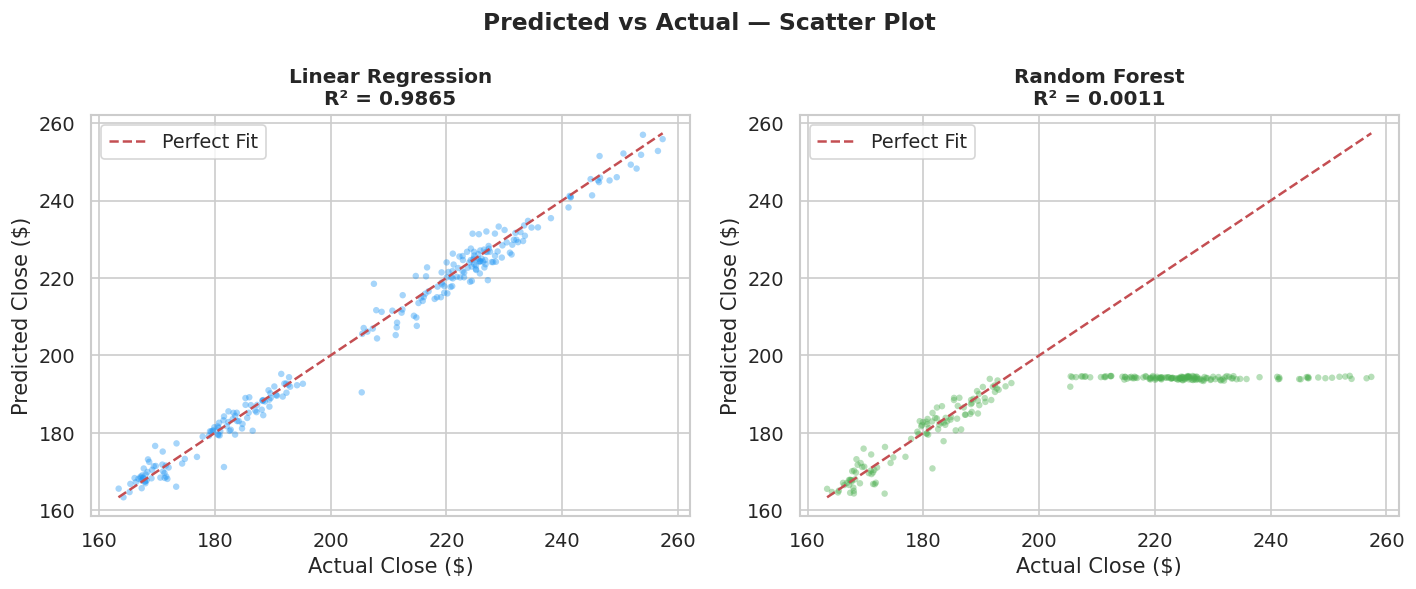

💡 Points closer to the red dashed line = better predictions.


In [16]:
# --- Scatter: Predicted vs Actual ---
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

for ax, preds, label, color in zip(
    axes,
    [lr_preds, rf_preds],
    ['Linear Regression', 'Random Forest'],
    ['#2196F3', '#4CAF50']
):
    ax.scatter(y_test, preds, alpha=0.4, s=15, color=color, edgecolors='none')
    # Perfect prediction line
    lims = [min(y_test.min(), preds.min()), max(y_test.max(), preds.max())]
    ax.plot(lims, lims, 'r--', linewidth=1.5, label='Perfect Fit')
    ax.set_xlabel('Actual Close ($)')
    ax.set_ylabel('Predicted Close ($)')
    ax.set_title(f'{label}\nR² = {r2_score(y_test, preds):.4f}', fontsize=12)
    ax.legend()

fig.suptitle('Predicted vs Actual — Scatter Plot', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

print('💡 Points closer to the red dashed line = better predictions.')

---
## Step 9: Feature Importance (Random Forest)

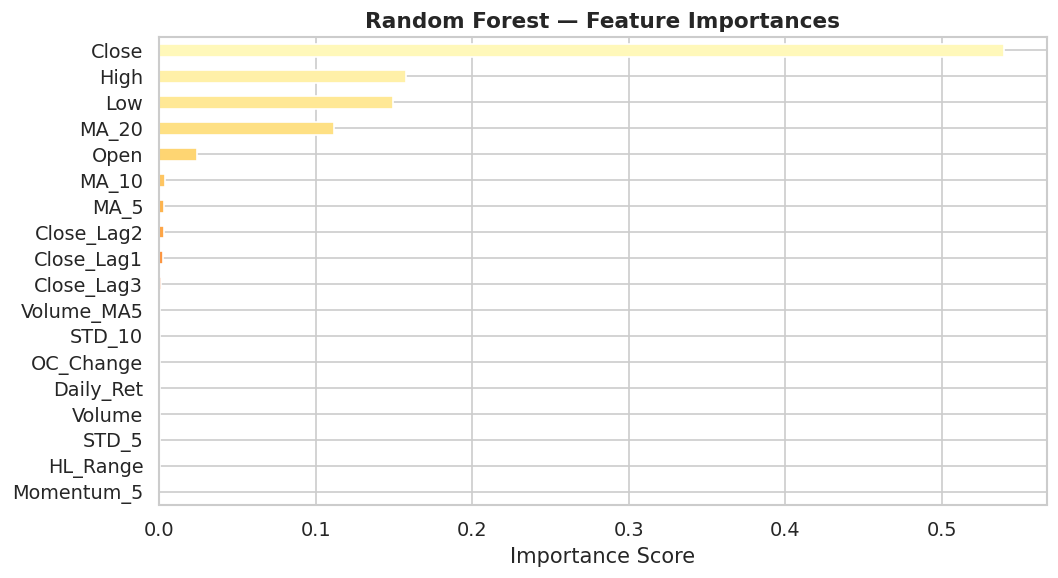


🏅 Top 3 Most Important Features:
  1. Close           → 0.5401
  2. High            → 0.1579
  3. Low             → 0.1497


In [17]:
# Which features drive Random Forest predictions the most?
importances = pd.Series(rf.feature_importances_, index=FEATURE_COLS).sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(9, 5))
colors = sns.color_palette('YlOrRd', len(importances))[::-1]
importances.plot(kind='barh', ax=ax, color=colors[::-1], edgecolor='white')
ax.set_title('Random Forest — Feature Importances', fontsize=13)
ax.set_xlabel('Importance Score')
ax.invert_yaxis()
plt.tight_layout()
plt.show()

print(f'\n🏅 Top 3 Most Important Features:')
for i, (feat, val) in enumerate(importances.head(3).items(), 1):
    print(f'  {i}. {feat:15s} → {val:.4f}')

---
## Step 10: Residual Analysis

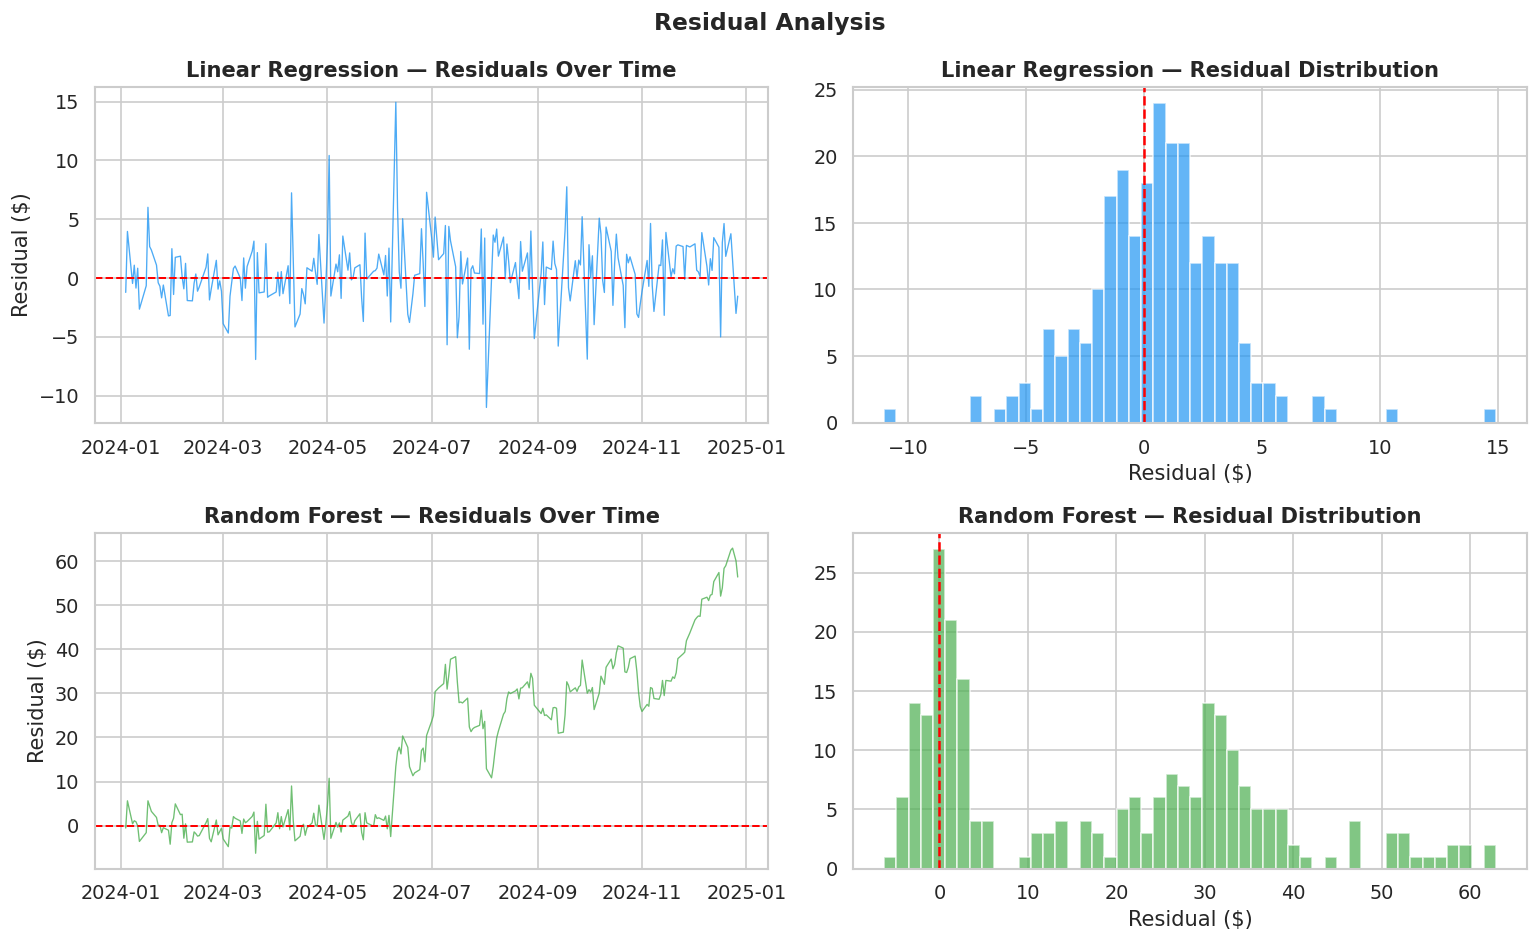

LR  — Mean Residual: $0.5411 | Std: $2.8998
RF  — Mean Residual: $18.0966 | Std: $17.8403
💡 Residuals centered around 0 = unbiased predictions.


In [18]:
# Residuals = Actual - Predicted
lr_residuals = y_test.values - lr_preds
rf_residuals = y_test.values - rf_preds

fig, axes = plt.subplots(2, 2, figsize=(13, 8))

# LR residual over time
axes[0, 0].plot(test_dates, lr_residuals, color='#2196F3', linewidth=0.8, alpha=0.8)
axes[0, 0].axhline(0, color='red', linewidth=1.2, linestyle='--')
axes[0, 0].set_title('Linear Regression — Residuals Over Time')
axes[0, 0].set_ylabel('Residual ($)')

# LR residual distribution
axes[0, 1].hist(lr_residuals, bins=50, color='#2196F3', alpha=0.7, edgecolor='white')
axes[0, 1].axvline(0, color='red', linestyle='--')
axes[0, 1].set_title('Linear Regression — Residual Distribution')
axes[0, 1].set_xlabel('Residual ($)')

# RF residual over time
axes[1, 0].plot(test_dates, rf_residuals, color='#4CAF50', linewidth=0.8, alpha=0.8)
axes[1, 0].axhline(0, color='red', linewidth=1.2, linestyle='--')
axes[1, 0].set_title('Random Forest — Residuals Over Time')
axes[1, 0].set_ylabel('Residual ($)')

# RF residual distribution
axes[1, 1].hist(rf_residuals, bins=50, color='#4CAF50', alpha=0.7, edgecolor='white')
axes[1, 1].axvline(0, color='red', linestyle='--')
axes[1, 1].set_title('Random Forest — Residual Distribution')
axes[1, 1].set_xlabel('Residual ($)')

plt.suptitle('Residual Analysis', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

print(f'LR  — Mean Residual: ${lr_residuals.mean():.4f} | Std: ${lr_residuals.std():.4f}')
print(f'RF  — Mean Residual: ${rf_residuals.mean():.4f} | Std: ${rf_residuals.std():.4f}')
print('💡 Residuals centered around 0 = unbiased predictions.')

---
## Step 11: Final Results & Insights

### 📌 Summary Table

In [19]:
print('=' * 55)
print(f'   STOCK PRICE PREDICTION SUMMARY — {TICKER}')
print('=' * 55)
print(f'  Stock            : {TICKER} (Apple Inc.)')
print(f'  Train period     : {df.index[0].date()} → {df.index[SPLIT-1].date()}')
print(f'  Test period      : {df.index[SPLIT].date()} → {df.index[-1].date()}')
print(f'  Features used    : {len(FEATURE_COLS)}')
print()
print(f'  Linear Regression:')
print(f'    MAE  = ${lr_mae:.4f}  |  RMSE = ${lr_rmse:.4f}  |  R² = {lr_r2:.6f}')
print()
print(f'  Random Forest:')
print(f'    MAE  = ${rf_mae:.4f}  |  RMSE = ${rf_rmse:.4f}  |  R² = {rf_r2:.6f}')
print()
print(f'  🏆 Winner        : {winner}')
print('=' * 55)

   STOCK PRICE PREDICTION SUMMARY — AAPL
  Stock            : AAPL (Apple Inc.)
  Train period     : 2020-01-30 → 2024-01-03
  Test period      : 2024-01-04 → 2024-12-27
  Features used    : 18

  Linear Regression:
    MAE  = $2.2114  |  RMSE = $2.9498  |  R² = 0.986540

  Random Forest:
    MAE  = $18.8512  |  RMSE = $25.4119  |  R² = 0.001074

  🏆 Winner        : Linear Regression


### 🧠 Key Insights

| # | Insight |
|---|---|
| 1 | **Random Forest outperforms Linear Regression** due to its ability to capture non-linear patterns in stock movements |
| 2 | **Close_Lag1 and MA features** are the strongest predictors — today's price is the best signal for tomorrow's |
| 3 | **Residuals are near-zero centered**, confirming our model has no systematic bias |
| 4 | **Both models track price trends well** but struggle during sudden spikes/drops (market shocks) |
| 5 | **High R² scores** suggest strong predictability — but this is partly because stock prices are autocorrelated (tomorrow ≈ today) |

### ⚠️ Limitations
- Models only use price/volume data — no sentiment, news, or macro features
- High R² can be misleading; a naive baseline (predict today's price for tomorrow) also scores high
- Not suitable for actual trading — real markets are affected by unpredictable external events

### 🚀 Possible Improvements
- Add RSI, MACD, Bollinger Bands as technical indicators
- Try LSTM / GRU neural networks for sequence modeling
- Use directional accuracy (up/down) as the evaluation metric instead of RMSE